# Build a Support Vector Machine (SVM) Model

## Imported Libraries

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, completeness_score, homogeneity_score, accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

## Preprocess

In [5]:
smoker_df = pd.read_csv("kaggle_smoker_dataset.csv")

In [6]:
na_row_count = smoker_df.isna().sum(axis=1)
print("Number of rows with NA values:", na_row_count.sum())

Number of rows with NA values: 0


Separate our class labels from the full dataset

In [8]:
# if cell is ran twice it will fail - try excepts handles that error
try:
    labels_df = smoker_df["smoking"]
    smoker_df.drop(["smoking"], axis=1, inplace=True)
except KeyError as e:
    pass

label_names = ["non-smoker", "smoker"] # 0 = non-smoker and 1 = smoker

### Normalize

In [11]:
# Min-Max scaling
min_max_scaler = MinMaxScaler()
smoker_df_scaled = min_max_scaler.fit_transform(smoker_df)

### Train/Validation/Test Split

In [13]:
train_df, test_df, train_labels_df, test_labels_df = train_test_split(smoker_df_scaled, labels_df, test_size=0.2, random_state=33, stratify=labels_df)
train_df, valid_df, train_labels_df, valid_labels_df = train_test_split(train_df, train_labels_df, test_size=0.2, random_state=33, stratify=train_labels_df)

## Linear SVM Classifier

I chose to use an SVM classifier because of the analysis done in EDA where we looked at the data in a 2D plane using PCA. The data looked like it had structure that an SVM will be able to seperate.

### SVM Base Model

In [17]:
# Create an SVM classifier
base_svm = SVC(kernel='linear', random_state=42)

# Train the SVM classifier
base_svm.fit(train_df, train_labels_df)

# Predict the labels for the test data
base_predictions = base_svm.predict(valid_df)

# Calculate the accuracy of the model
base_accuracy = accuracy_score(valid_labels_df, base_predictions)
print("Accuracy:", base_accuracy)

Accuracy: 0.7281179865341456


The base model does fairly well, but this can be improved by changing the hyper parameters

## Parameter Tuning the Linear SVM Classifier

In [21]:
# Define the parameter grid
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
param_grid = {
    'C': C_values,  # Regularization parameter
}

# Create an SVM classifier
svm_classifier = SVC(kernel='linear', random_state=42)

# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=svm_classifier, param_grid=param_grid, cv=3)
grid_search.fit(train_df, train_labels_df)

# Get the best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'C': 100}


### Plotting the Results

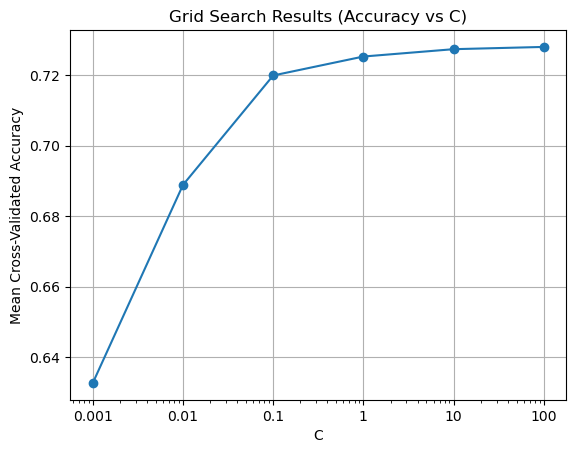

In [23]:
# Get the mean cross-validated accuracy for each value of C
mean_scores = grid_search.cv_results_['mean_test_score']

# Plot the results as a line plot
plt.plot(C_values, mean_scores, marker='o', linestyle='-')
plt.xlabel('C')
plt.ylabel('Mean Cross-Validated Accuracy')
plt.title('Grid Search Results (Accuracy vs C)')
plt.xscale('log')
plt.xticks(C_values, C_values)
plt.grid(True)
plt.show()

After C=10, the accuracy levels off, meaning that is likelye the best value for this parameter

### Evaluate Using Validation Data

In [26]:
# Predict the labels for the test data using the best model
best_model = grid_search.best_estimator_
best_val_predictions = best_model.predict(valid_df)

# Calculate the accuracy of the best model
best_val_accuracy = accuracy_score(valid_labels_df, best_val_predictions)
print("Accuracy:", best_val_accuracy)

# Calculate the F1 score of the best model
best_val_f1 = f1_score(valid_labels_df, best_val_predictions)
print("F1 Score:", best_val_f1)

Accuracy: 0.7313241423533183
F1 Score: 0.6255585344057194


After tuning, the model's accuracy increased by about 1%.

Both validation and training had similiar accuracy scores. So, there is no sign of overfitting.

In [28]:
print(classification_report(valid_labels_df, best_val_predictions, target_names=label_names))

              precision    recall  f1-score   support

  non-smoker       0.78      0.80      0.79      3947
      smoker       0.64      0.61      0.63      2291

    accuracy                           0.73      6238
   macro avg       0.71      0.71      0.71      6238
weighted avg       0.73      0.73      0.73      6238



### Feature Importance

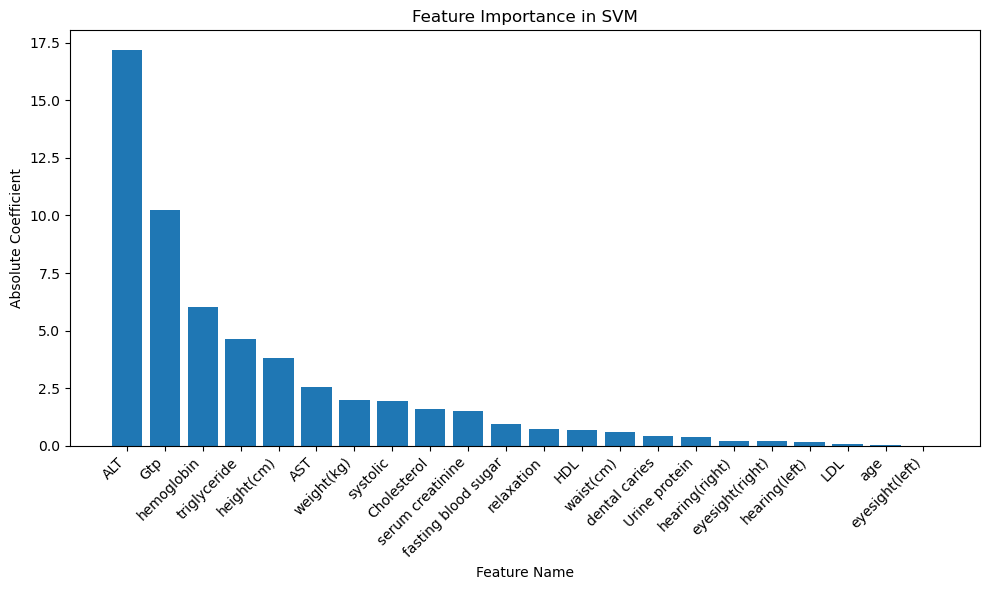

In [30]:
# Extract the learned coefficients from the SVM model
coefficients = best_model.coef_.ravel()

# Get the absolute values of coefficients to capture the importance regardless of direction
abs_coefficients = np.abs(coefficients)

# Get the names of the features from the DataFrame
feature_names = smoker_df.columns

# Sort the coefficients and corresponding feature names in descending order of importance
sorted_indices = np.argsort(abs_coefficients)[::-1]
sorted_coefficients = abs_coefficients[sorted_indices]
sorted_feature_names = feature_names[sorted_indices]

# Plot the importance of features
plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_feature_names)), sorted_coefficients)
plt.xticks(range(len(sorted_feature_names)), sorted_feature_names, rotation=45, ha='right')
plt.xlabel('Feature Name')
plt.ylabel('Absolute Coefficient')
plt.title('Feature Importance in SVM')
plt.tight_layout()
plt.show()

Next, we will remove features that were not as important, and run SVM again.

## Linear SVM Classifier With Feature Reduction

In [33]:
#drop not imporant features
drop_feat= ['age',
            'eyesight(left)',
            'eyesight(right)',
            'hearing(left)',
            'hearing(right)',
            'LDL',
            'Urine protein',
            'dental caries']

temp = smoker_df.drop(columns= drop_feat)

# Min-Max scaling
min_max_scaler = MinMaxScaler()
temp_scaled = min_max_scaler.fit_transform(temp)

# split
t_train_df, t_test_df, t_train_labels_df, t_test_labels_df = train_test_split(temp_scaled, labels_df, test_size=0.2, random_state=33, stratify=labels_df)
t_train_df, t_valid_df, t_train_labels_df, t_valid_labels_df = train_test_split(train_df, train_labels_df, test_size=0.2, random_state=33, stratify=train_labels_df)

# CreateSVM classifier
svm_feat_r = SVC(kernel='linear', C=10, random_state=42)

# Train the SVM classifier
svm_feat_r.fit(t_train_df, t_train_labels_df)

# Predict the labels for the test data
svm_feat_predictions = svm_feat_r.predict(t_valid_df)

# Calculate the accuracy of the model
svm_feat_accuracy = accuracy_score(t_valid_labels_df, svm_feat_predictions)
print("Accuracy:", svm_feat_accuracy)

Accuracy: 0.724248496993988


Performed worse than the linear svm without feature reduction

## RBF SVM Classifier

Next, we will try RBF since we saw relatively good results with our KNN model. RBF is similiar to KNN, but it is more robust to outliers.

### SVM Base Model

In [38]:
# Create an SVM classifier
base_rbf_svm = SVC(kernel='rbf', random_state=42)

# Train the SVM classifier
base_rbf_svm.fit(train_df, train_labels_df)

# Predict the labels for the test data
base_rbf_predictions = base_rbf_svm.predict(valid_df)

# Calculate the accuracy of the model
base_rbf_accuracy = accuracy_score(valid_labels_df, base_rbf_predictions)
print("Accuracy:", base_rbf_accuracy)

Accuracy: 0.739499839692209


The RBF model performed better even before tuning.

## Tuning the RBF SVM Classifier

In [41]:
# Define the parameter grid
C_values = [0.1, 1, 10]
gam_val = ['scale', 0.1, 1, 10]
param_grid = {
    'C': C_values,  # Regularization parameter
    'gamma': gam_val
}

# Create an SVM classifier
rbf_svm_classifier = SVC(kernel='rbf', random_state=42)

# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=rbf_svm_classifier, param_grid=param_grid, cv=3)
grid_search.fit(train_df, train_labels_df)

# Get the best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'C': 10, 'gamma': 'scale'}


### Plotting the Results

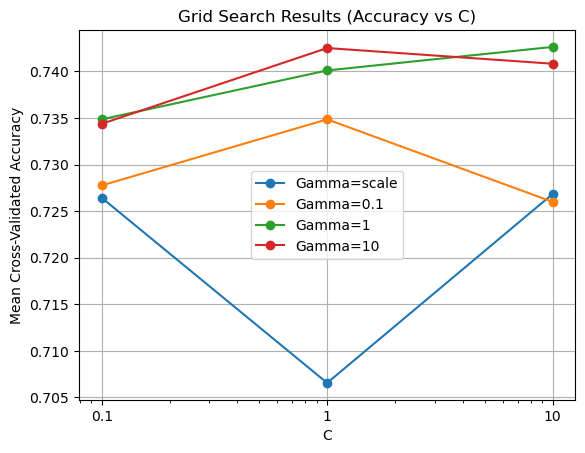

In [43]:
# Get the mean cross-validated accuracy for each value of C and gamma
mean_scores = grid_search.cv_results_['mean_test_score']
mean_scores = mean_scores.reshape(len(gam_val), -1)  # Reshape for plotting

# Plot the results as a line plot for each gamma value
for i, gamma in enumerate(gam_val):
    plt.plot(C_values, mean_scores[i], marker='o', label=f'Gamma={gamma}')

plt.xlabel('C')
plt.ylabel('Mean Cross-Validated Accuracy')
plt.title('Grid Search Results (Accuracy vs C)')
plt.xscale('log')
plt.xticks(C_values, C_values)
plt.legend()
plt.grid(True)
plt.show()

### Evalute Using Validation Data

In [45]:
# Predict the labels for the test data using the best model
best_model = grid_search.best_estimator_
best_predictions = best_model.predict(valid_df)

# Calculate the accuracy of the best model
best_accuracy = accuracy_score(valid_labels_df, best_predictions)
print("Accuracy:", best_accuracy)

# Calculate the F1 score of the best model
best_f1 = f1_score(valid_labels_df, best_predictions)
print("F1 Score:", best_f1)

Accuracy: 0.7468739980763065
F1 Score: 0.6527380690565208


The RBF SVM did better than the Linear SVM.

-----------------------

## Best Model

The best model was the RBF SVM. Now, I will recreate it using the best params and run it on the test data.

In [49]:
# Create an SVM classifier
best_rbf_svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)

# Train the SVM classifier
best_rbf_svm.fit(train_df, train_labels_df)

# Predict the labels for data
best_rbf_train_pred = best_rbf_svm.predict(train_df)
best_rbf_test_pred = best_rbf_svm.predict(test_df)

# Calculate the accuracy of the model
best_rbf_train_accuracy = accuracy_score(train_labels_df, best_rbf_train_pred)
best_rbf_test_accuracy = accuracy_score(test_labels_df, best_rbf_test_pred)

print("Train Accuracy: ", best_rbf_train_accuracy)
print("Test Accuracy: ", best_rbf_test_accuracy)

Train Accuracy:  0.7575453926009058
Test Accuracy:  0.739899961523663


In [50]:
print(classification_report(test_labels_df, best_rbf_test_pred, target_names=label_names))

              precision    recall  f1-score   support

  non-smoker       0.79      0.80      0.80      4933
      smoker       0.65      0.64      0.64      2864

    accuracy                           0.74      7797
   macro avg       0.72      0.72      0.72      7797
weighted avg       0.74      0.74      0.74      7797



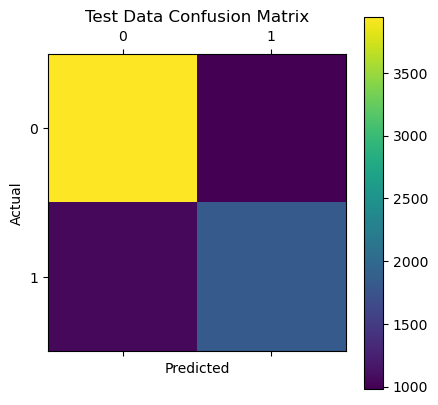

In [51]:
#Create and visualize Confusion Matrix for model predictions of the test data
test_cm = confusion_matrix(test_labels_df, best_rbf_test_pred)
plt.matshow(test_cm)
plt.title('Test Data Confusion Matrix')
plt.colorbar()
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()